# Packages and Functions

In [1]:
import numpy as np; 
import pandas as pd; 
import matplotlib.pyplot as plt; 
plt.rcParams['figure.figsize'] = (10, 2);
from gprMax.utilities import detect_check_gpus; 
from gprMax.gprMax import api; 
import h5py; 
detect_check_gpus([1]);
import os; 
import torch
import time; 
from IPython.display import clear_output; 
os.getcwd(); 
from GPUtil import showUtilization as gpu_usage
from numba import cuda; 
import gc; 
import pycuda.driver; 
import random; 
from scipy.signal import hilbert
from bayes_opt import BayesianOptimization; 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Three material layers

## Load data recorded by multi-receiver radar

Number of Rx waveforms: 9
Rx positions [m]: [0.15 0.5  0.9  1.2  1.5  1.8  2.1  2.4  2.68]


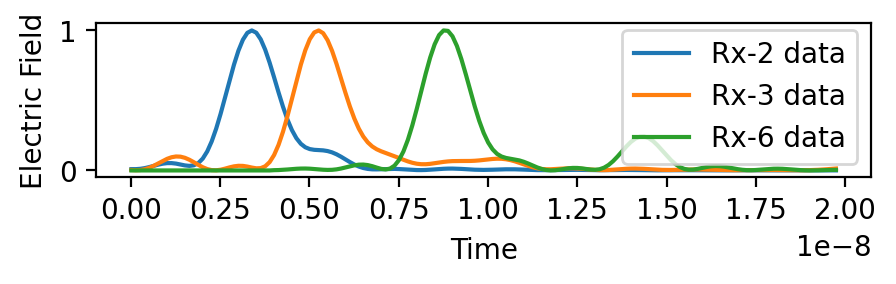

In [ ]:
# Change first two lines if other material layer cases are to be used
data = np.load('Experimental_data/WS(wet)90-Str90-Sand90(wet).npz')  # Load one of the 3-material-layer cases: Air90-WS(wet)90-Str90;   WS(wet)85-Str90-Sand95;   WS(wet)90-Str90-Sand90(wet)
p12, p23 = 0.9,  0.9 + 0.9                                  # p12 = Layer 1-2 interface and p23 = Layer 2-3 interface [metres]

t_values = data['t']
nt = len(t_values)
Rx_positions_exp = data['Rx']


# Extract amplitude keys (a1, a2, ..., aN)
a_keys = sorted([key for key in data.files if key.startswith('a') and data[key].ndim >= 1])
Rx_data = [data[a_key] for a_key in a_keys]
print(f"Number of Rx waveforms: {len(Rx_data)}\nRx positions [m]: {data['Rx']}")

Rx_positions = list(data['Rx'])
num_receivers = len(Rx_positions)

df_exp = pd.DataFrame({
    'x': np.concatenate([np.full(nt, x) for x in Rx_positions]),
    't': np.tile(t_values, num_receivers),
    'Rx': np.concatenate(Rx_data),
})

# Plot a few recorded signals
plt.figure(figsize=(5, 1), dpi=200)
nnn=2; plt.plot(df_exp['t'][-t_values.shape[0]:], df_exp['Rx'][(nnn-1)*t_values.shape[0]:(nnn)*t_values.shape[0]], label=f'Rx-{nnn} data')
nnn=3; plt.plot(df_exp['t'][-t_values.shape[0]:], df_exp['Rx'][(nnn-1)*t_values.shape[0]:(nnn)*t_values.shape[0]], label=f'Rx-{nnn} data')
nnn=6; plt.plot(df_exp['t'][-t_values.shape[0]:], df_exp['Rx'][(nnn-1)*t_values.shape[0]:(nnn)*t_values.shape[0]], label=f'Rx-{nnn} data')
plt.xlabel('Time'); 
plt.ylabel('Electric Field'); 
plt.legend(); 
plt.show()

## Simulation (FDTD) model

In [3]:
def model_discrete(e1, e2=None, e3=None, p12=None, p23=None, num_layers=3, 
                   Lx=1.0, Tmax=25e-9, Rx_positions=None, delay_ns=0.0, show_animation=False):
    # --- Physical constants ---
    f0 = 0.5e9
    e0 = 8.854e-12
    u0 = 4 * np.pi * 1e-7
    c0 = 1 / np.sqrt(e0 * u0)
    Lf = 50
    Nx = int(Lx * Lf)
    x = np.linspace(0, Lx, Nx)
    dx = x[1] - x[0]

    dt = dx / (2 * c0) * 0.99
    nt = int(Tmax / dt)
    t_values = np.arange(nt) * dt

    # --- Permittivity profile ---   
    e_r = np.ones(Nx)

    if num_layers == 1:
        e_r[:] = e1
    elif num_layers == 2 and e2 is not None and p12 is not None:
        idx12 = int(p12 / dx)
        e_r[:idx12] = e1
        e_r[idx12:] = e2
    elif num_layers == 3 and e2 is not None and e3 is not None and p12 is not None and p23 is not None:
        idx12 = int(p12 / dx)
        idx23 = int(p23 / dx)
        e_r[:idx12] = e1
        e_r[idx12:idx23] = e2
        e_r[idx23:] = e3
    else:
        raise ValueError("Invalid layer configuration.")

    eps = e0*e_r
    c = 1 / np.sqrt(eps * u0)
    CFL = c * dt / dx

    Rx_indices = [int(pos / dx) for pos in Rx_positions]
    Rx_data = [[] for _ in Rx_positions]

    Tx_position = Rx_positions[0] -0.02
    if Tx_position < 0:
        raise ValueError("Tx would be outside the domain.")
    Tx_idx = int(Tx_position / dx)

    Ef = np.zeros((Nx, 3))

    for k in range(nt):
        Ef[0, 2]  = Ef[1, 1]  + ((CFL[0]  - 1) / (CFL[0]  + 1)) * (Ef[1, 2]  - Ef[0, 1])
        Ef[-1, 2] = Ef[-2, 1] + ((CFL[-1] - 1) / (CFL[-1] + 1)) * (Ef[-2, 2] - Ef[-1, 1])
        Ef[:, :2] = Ef[:, 1:]

        if t_values[k] < t_values[60]:
            Ef[Tx_idx, 1] = 20 * (np.sin(2 * np.pi * f0 * dt * k) * np.exp(-0.5 * ((k - 20) / 25)**2))

        for i in range(1, Nx - 1):
            Ef[i, 2] = 2 * Ef[i, 1] - Ef[i, 0] + CFL[i]**2 * (Ef[i + 1, 1] - 2 * Ef[i, 1] + Ef[i - 1, 1])

        for i, idx in enumerate(Rx_indices):
            Rx_data[i].append(Ef[idx, 1])

        if show_animation and k % 20 == 0:
            plt.figure(figsize=(6, 2.5), dpi=200)
            plt.clf()
            plt.title(f'Time = {1e9 * t_values[k]:.2f} ns')
            plt.ylim([-15, 25])
            plt.plot(x, Ef[:, 1], linewidth=2, color='red', label='E-field')
            plt.scatter(x[Tx_idx], 0, label='Tx', color='black', s=50)
            plt.scatter(Rx_positions, np.zeros_like(Rx_positions), label='Rx', marker='<', s=75, color='blue')
            if num_layers == 2:
                plt.axvspan(0, x[int(p12/dx)], color='blue', alpha=0.1)
                plt.axvspan(x[int(p12/dx)], Lx, color='gray', alpha=0.15)
            elif num_layers == 3:
                plt.axvspan(0, x[int(p12/dx)], color='blue', alpha=0.1)
                plt.axvspan(x[int(p12/dx)], x[int(p23/dx)], color='gray', alpha=0.15)
                plt.axvspan(x[int(p23/dx)], Lx, color='green', alpha=0.15)
            plt.ylabel('Electric Field')
            plt.legend()
            plt.tight_layout()
            plt.show()
            clear_output(wait=True)
            time.sleep(0.0001)
    plt.close()

    Rx_data = [np.array(rx) for rx in Rx_data]    # Convert list to arrays

    # --- Apply delay = delay_ns---
    delay_steps = int((delay_ns * 1e-9) / dt)
    Rx_delayed = []
    for rx in Rx_data:
        shifted = np.roll(rx, delay_steps)
        shifted[:delay_steps] = 0
        Rx_delayed.append(shifted)

    return Rx_delayed, t_values


### Example simulation

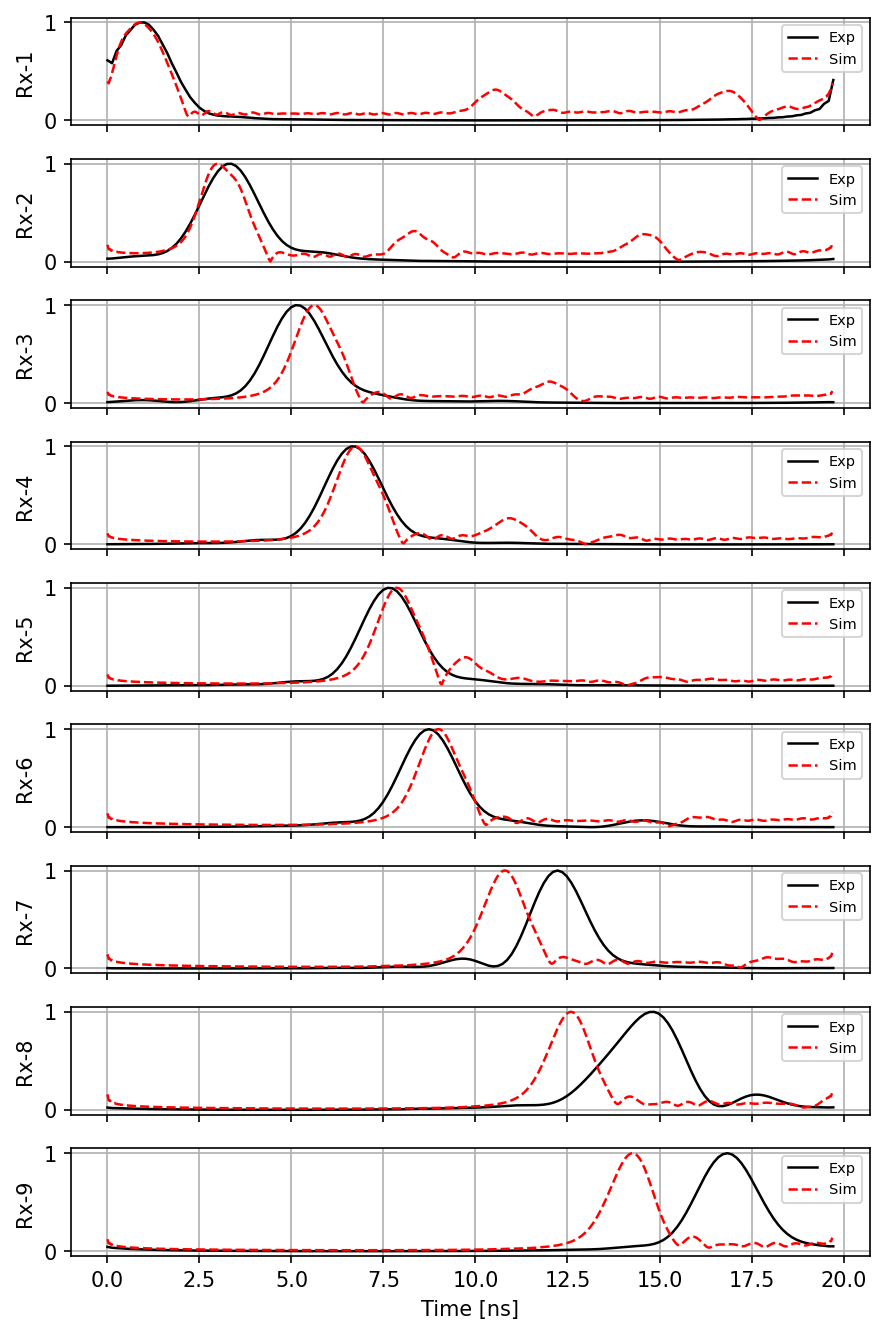

In [4]:
# --- Parameters ---
Lx = Rx_positions_exp[-1] + 0.02
Tmax = t_values[-1]         # Use the last time value from the experiment, this will be total simulation time

delay_ns = 0.0  # Delay in nanoseconds
e1, e2, e3 = 3.5, 1.2, 3

# --- Run model --- 
# For 1-Layer model, use e1 only
# For 2-Layer model, use e1, e2, and p12
# For 3-Layer model, use e1, e2, e3, p12, and p23
Rx, T = model_discrete(e1, e2, e3, p12=p12, p23=p23, num_layers=3, Lx=Lx, Tmax=Tmax, Rx_positions=Rx_positions_exp, delay_ns=0, show_animation=True)

# Step 1: Get time and amplitude keys
t_exp = 1e9 * data['t']  # Convert time to nanoseconds
t_exp -= t_exp.min()
nt = len(t_exp)

# Step 2: Extract experimental amplitudes
a_keys = sorted([key for key in data.files if key.startswith('a') and data[key].ndim >= 1])
num_rx = len(Rx)
fig, axes = plt.subplots(num_rx, 1, figsize=(6, 1.0 * num_rx), dpi=150, sharex=True)

# Step 3: Plot each receiver
for i, ax in enumerate(axes):
    # --- Experimental data ---
    a_exp_raw = data[a_keys[i]]
    a_exp_env = np.abs(hilbert(a_exp_raw))
    a_exp_norm = a_exp_env / np.max(a_exp_env); a_exp_norm = a_exp_norm**2

    # --- Simulated data ---
    t_sim = 1e9 * T
    a_sim_raw = Rx[i]
    a_sim_env = np.abs(hilbert(a_sim_raw))
    a_sim_norm = a_sim_env / np.max(a_sim_env)

    # Plot both
    ax.plot(t_exp, a_exp_norm, label='Exp', color='black', lw=1.2)
    ax.plot(t_sim, a_sim_norm, label='Sim', color='red', linestyle='--', lw=1.2)
    ax.set_ylabel(f'Rx-{i+1}')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True)

axes[-1].set_xlabel('Time [ns]')
plt.tight_layout()
plt.show()

## Model-updating using Bayesian optimization

In [7]:
from scipy.interpolate import interp1d
t_exp = data['t']
Rx_data_exp = np.concatenate(Rx_data, axis=0)

# Envelope and normalization
A_exp = np.abs(hilbert(Rx_data_exp))
A_exp /= np.max(A_exp); 
A_exp = A_exp**2


def objective_3layers(e1, e2, e3):
    Lx = Rx_positions_exp[-1] + 0.02
    Tmax = t_exp[-1]

    # Simulate waveform
    Rx_sim, T_sim = model_discrete(e1=e1, e2=e2, e3=e3, p12=p12, p23=p23, num_layers=3, Lx=Lx, 
                                   Tmax=Tmax, Rx_positions=Rx_positions_exp)
    A_sim = np.abs(hilbert(np.concatenate(Rx_sim)))
    A_sim /= np.max(A_sim)

    # Interpolate to match length of simulated and experimental signals
    interp_func = interp1d(np.linspace(0, Tmax, len(A_sim)), A_sim, kind='cubic', fill_value="extrapolate")
    A_sim_interp = interp_func(np.linspace(0, Tmax, len(A_exp)))

    # Compute normalized RMSE
    rmse = np.sqrt(np.mean((A_exp - A_sim_interp) ** 2))
    normalized_rmse = -100 * rmse / np.sqrt(np.mean(A_exp**2))
    return normalized_rmse


from bayes_opt import BayesianOptimization

bounds = {'e1': (1, 15), 'e2': (1, 15), 'e3': (1, 15)}      # Bounds of permittivity values

e1_vals = [];   
e2_vals = [];   
e3_vals = [];   
scores = [];

num_runs = 5  # Number of optimization runs
for run in range(num_runs):
    print(f"\n--- Optimization Run {run+1} ---")
    optimizer = BayesianOptimization(f=objective_3layers, pbounds=bounds, verbose=0)
    optimizer.maximize(init_points=60, n_iter=40)

    best_params = optimizer.max['params']
    e1_vals.append(best_params['e1'])
    e2_vals.append(best_params['e2'])
    e3_vals.append(best_params['e3'])
    scores.append(optimizer.max['target'])

    print(f"Run {run+1} best e1: {best_params['e1']:.4f}, e2: {best_params['e2']:.4f}, e3: {best_params['e3']:.4f}, Score: {optimizer.max['target']:.4f}")

# Convert to arrays for statistics
e1_vals = np.array(e1_vals)
e2_vals = np.array(e2_vals)
e3_vals = np.array(e3_vals)
scores = np.array(scores)

print("\n--- Mean and std of 5 Runs ---")
print(f"e1 mean: {e1_vals.mean():.2f}, std: {e1_vals.std():.2f}")
print(f"e2 mean: {e2_vals.mean():.2f}, std: {e2_vals.std():.2f}")
print(f"e3 mean: {e3_vals.mean():.2f}, std: {e3_vals.std():.2f}")
print(f"Objective score mean: {scores.mean():.2f}, std: {scores.std():.2f}")


--- Optimization Run 1 ---
Run 1 best e1: 2.5934, e2: 1.8350, e3: 6.8733, Score: -49.2789

--- Optimization Run 2 ---
Run 2 best e1: 2.7423, e2: 2.1553, e3: 5.2942, Score: -46.3800

--- Optimization Run 3 ---
Run 3 best e1: 2.8348, e2: 1.9014, e3: 5.8413, Score: -45.9223

--- Optimization Run 4 ---
Run 4 best e1: 3.0381, e2: 1.6919, e3: 5.7193, Score: -46.9732

--- Optimization Run 5 ---
Run 5 best e1: 2.7300, e2: 1.8922, e3: 5.8635, Score: -46.1465

--- Mean and std of 5 Runs ---
e1 mean: 2.79, std: 0.15
e2 mean: 1.90, std: 0.15
e3 mean: 5.92, std: 0.52
Objective score mean: -46.94, std: 1.22


## Signal alignment with predicted parameters

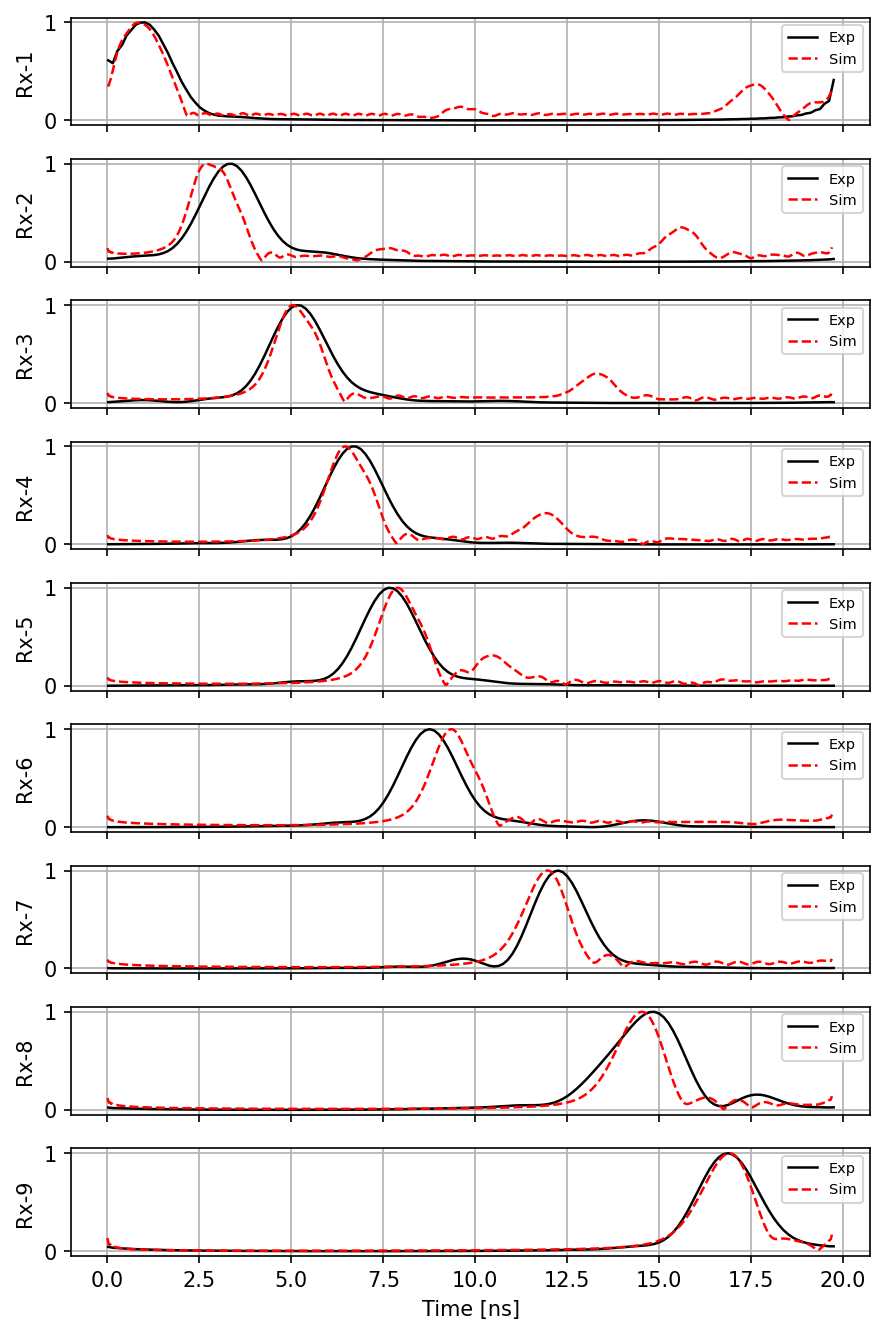

In [8]:
e1 = np.mean(e1_vals);  
e2 = np.mean(e2_vals); 
e3 = np.mean(e3_vals)

# Run simulation with estimated mean parameters
Rx, T = model_discrete(e1=e1, e2=e2, e3=e3, p12=p12, p23=p23, num_layers=3, Lx=Lx, Tmax=Tmax, Rx_positions=Rx_positions_exp, delay_ns=delay_ns, show_animation=True)

# --- Load experimental data ---
t_exp = 1e9 * data['t']  
nt = len(t_exp)

a_keys = sorted([key for key in data.files if key.startswith('a') and data[key].ndim >= 1])
num_rx = len(Rx)

# --- Plot envelopes for each Rx ---
fig, axes = plt.subplots(num_rx, 1, figsize=(6, 1.0 * num_rx), dpi=150, sharex=True)

for i, ax in enumerate(axes):
    # Experimental 
    a_exp_raw = data[a_keys[i]]
    a_exp_env = np.abs(hilbert(a_exp_raw))
    a_exp_norm = a_exp_env / np.max(a_exp_env)
    a_exp_norm = a_exp_norm**2 

    #  Simulated 
    t_sim = 1e9 * T
    a_sim_raw = Rx[i]
    a_sim_env = np.abs(hilbert(a_sim_raw))
    a_sim_norm = a_sim_env / np.max(a_sim_env)

    # Plot
    ax.plot(t_exp, a_exp_norm, label='Exp', color='black', lw=1.2)
    ax.plot(t_sim, a_sim_norm, label='Sim', color='red', linestyle='--', lw=1.2)
    ax.set_ylabel(f'Rx-{i+1}')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True)

axes[-1].set_xlabel('Time [ns]')
plt.tight_layout()
plt.show()
